In [1]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scienceplots
import numpy as np
import shap

c:\venvs\causal-inference\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.style.use(['science', 'notebook', 'grid'])

In [3]:
X_test = joblib.load("../data/splits/no_score/X_test.pkl")
y_test = joblib.load("../data/splits/no_score/y_test.pkl")
features = X_test.columns.tolist()

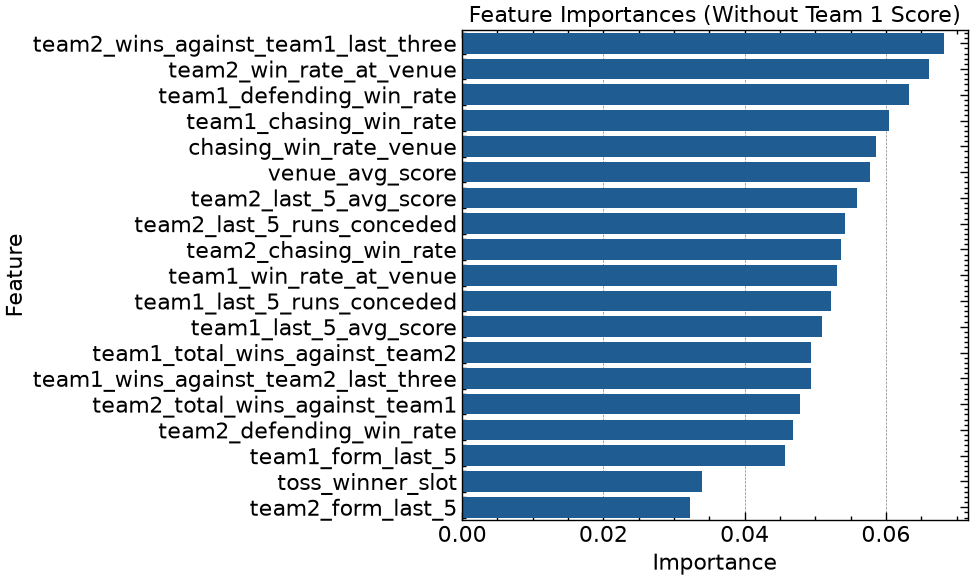

In [4]:
best_model = joblib.load("../models/production/no_score/best_model.pkl")

model = best_model.named_steps["classifier"]
importances = model.feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": features,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importances (Without Team 1 Score)")
plt.tight_layout()
plt.show()

### Key Observations from the Feature Importance Plot
- __team2_wins_against_team1_last_three__ is the most influential feature.
- Venue characterstics and head-to-head statistics dominate the top-ranked features.
- Defensive and bowling-related statistics provide moderate predictive information.
- Toss outcome has minimal impact on the model.

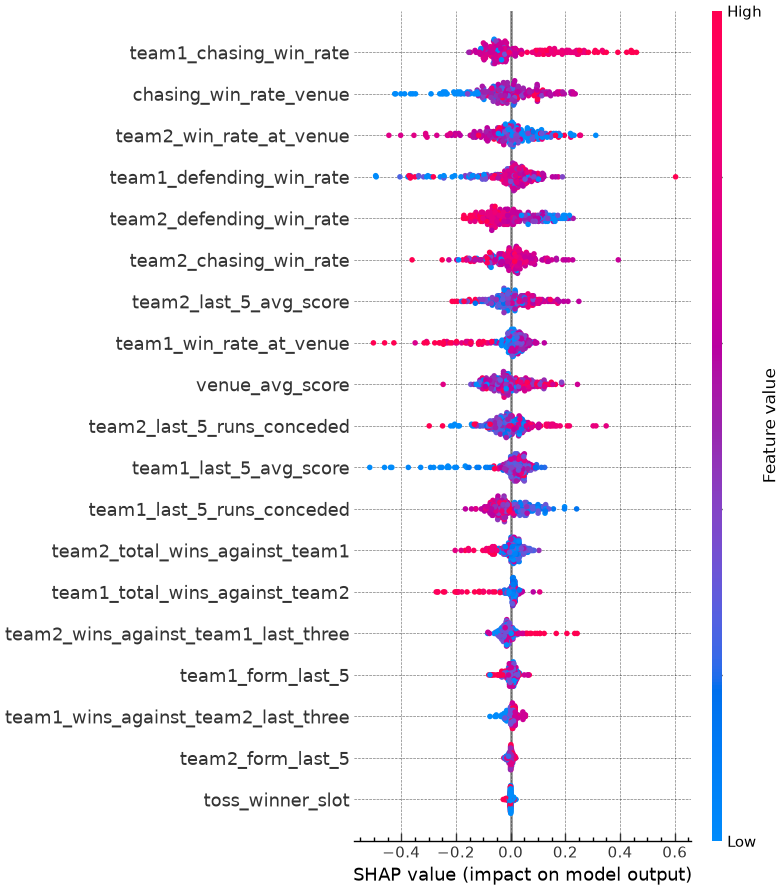

In [5]:
explainer = shap.Explainer(model)

shap_values = explainer(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names = X_test.columns
)

### Key observations from the SHAP Summary Plot
- __team1_chasing_win_rate__ has the largest overall impact on predictions.
- Venue-related and chasing statistics consistently influence model output.
- Lower-ranked features have SHAP values clustered near zero.
- Feature effects depend on interactions with other variables rather than simple linear relationships.

In [6]:
shap.initjs()

sample_idx = 0

shap.plots.force(
    base_value=shap_values.base_values[sample_idx],
    shap_values=shap_values.values[sample_idx],
    features=X_test.iloc[sample_idx],
    feature_names=X_test.columns,
)

### Key observations from the SHAP Force Plot
- Baseline probability is approximately **-0.1584**, while the final prediction is approximately **0.62**.
- Positive feature contributions dominate the prediction.
- Recent form and venue-related statistics exert the strongest influence.
- Negative contributions from head-to-head records and chasing statistic are comparatively smaller.
- The prediction results from the combined effect of multiple interacting features rather than any single statistic.

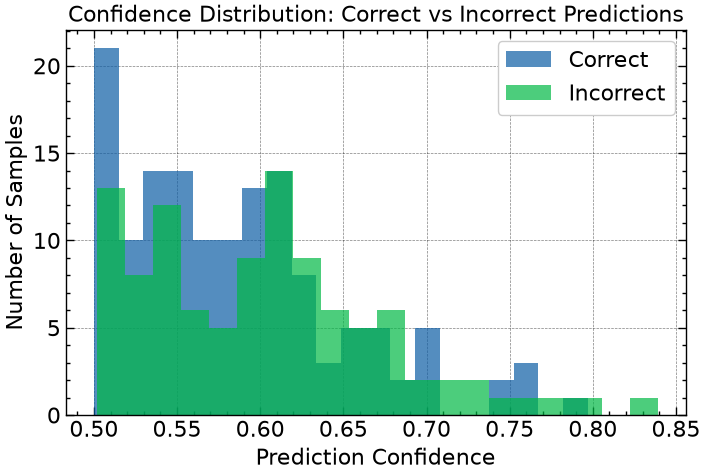

In [7]:
probs = model.predict_proba(X_test)
confidence = np.max(probs, axis=1)
predictions = model.predict(X_test)

correct = predictions == y_test.iloc[:,0]

plt.figure(figsize=(8, 5))

plt.hist(
    confidence[correct],
    bins=20,
    alpha=0.7,
    label="Correct"
)

plt.hist(
    confidence[~correct],
    bins=20,
    alpha=0.7,
    label="Incorrect"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Samples")
plt.title("Confidence Distribution: Correct vs Incorrect Predictions")
plt.legend()

plt.show()

The confidence distribution indicates that the classifier exhibits poor discrimination between correct and incorrect predictions. Both correct and incorrect predictions share a similar confidence range (approximately 0.50–0.65), resulting in substantial overlap between the two distributions. This overlap suggests that the model frequently assigns comparable confidence scores regardless of whether a prediction is correct, making confidence an unreliable indicator of prediction quality. Furthermore, while a few correct predictions receive relatively high confidence (>0.70), several incorrect predictions are also assigned similarly high confidence (up to approximately 0.84), indicating that the model is occasionally overconfident and its predicted probabilities are not well calibrated. These observations are consistent with the model's relatively low classification accuracy of approximately 57%, suggesting that the classifier has limited predictive power and that confidence values alone should not be interpreted as a reliable measure of correctness.

In [15]:
X_test = joblib.load("../data/splits/with_score/X_test.pkl")
y_test = joblib.load("../data/splits/with_score/y_test.pkl")
features = X_test.columns.tolist()

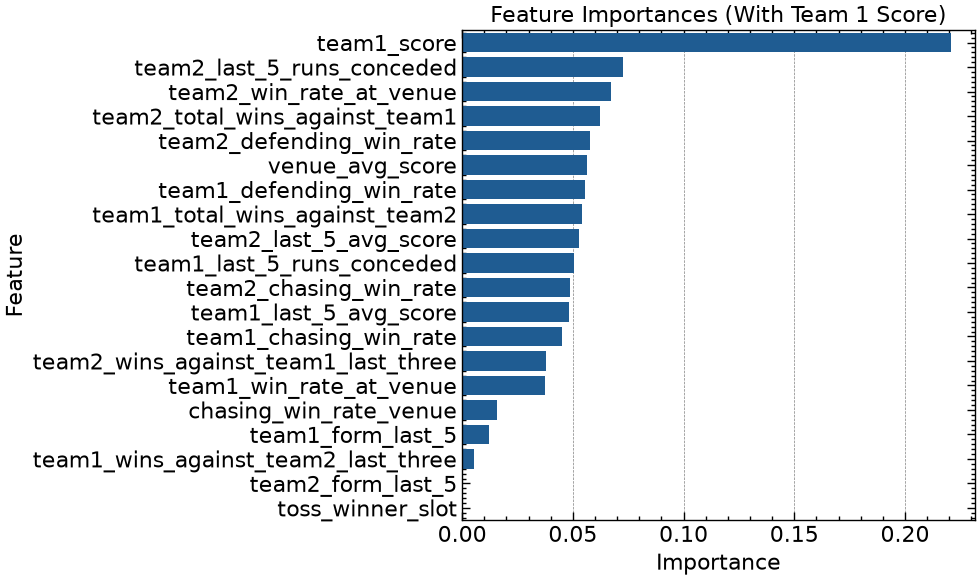

In [16]:
best_model = joblib.load("../models/production/with_score/best_model.pkl")

model = best_model.named_steps["classifier"]
importances = model.feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": features,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importances (With Team 1 Score)")
plt.tight_layout()
plt.show()

### Key observations from the Feature Importance Plot

- **team1_score** is the dominant predictor with the highest feature importance.
- Recent batting and bowling statistics remain useful supporting features.
- Venue characteristics continue to contribute meaningfully to prediction performance.
- Historical win rates become less influential once the actual Team 1 score is included.
- Toss outcome remains the least informative feature.

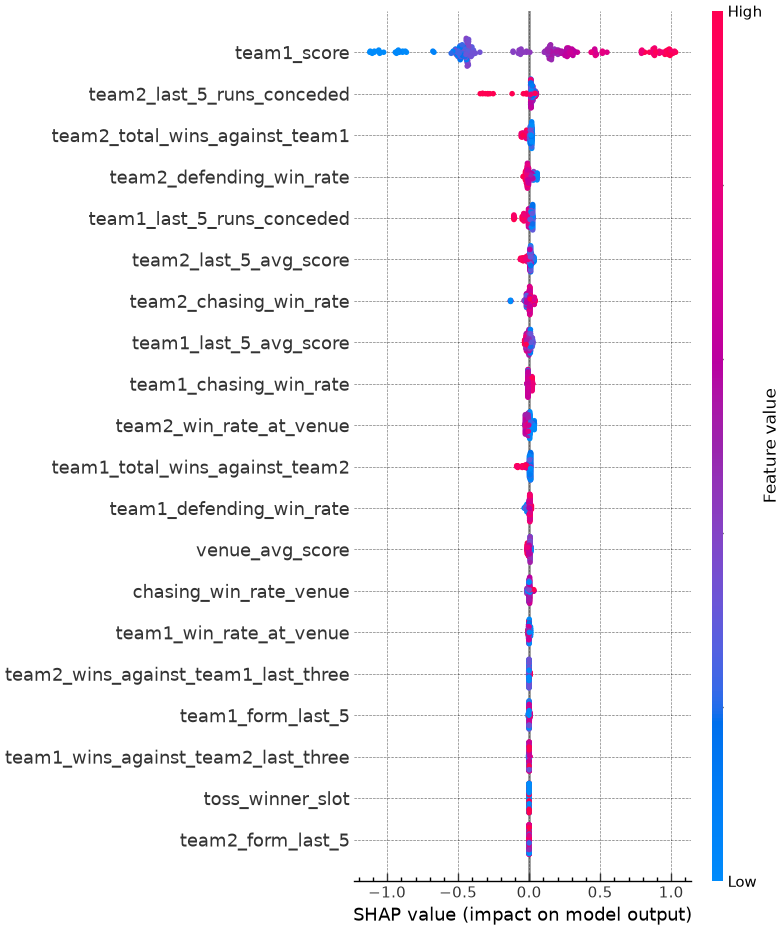

In [17]:
explainer = shap.Explainer(model)

shap_values = explainer(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names = X_test.columns
)

### Key observations from the SHAP Summary Plot

- **team1_score** has the largest impact on model output.
- Higher Team 1 scores consistently increase the predicted probability of winning.
- Historical team strengths provide supplementary predictive information.
- Recent form and toss outcome contribute minimally.
- The SHAP distribution indicates a strong and interpretable relationship between Team 1's score and prediction outcome

In [18]:
shap.initjs()

sample_idx = 0

shap.plots.force(
    base_value=shap_values.base_values[sample_idx],
    shap_values=shap_values.values[sample_idx],
    features=X_test.iloc[sample_idx],
    feature_names=X_test.columns,
)

### Key observations from SHAP Force Plot

- Baseline probability is approximately **-0.153**, while the final predicted probability decreases to approximately **0.19.**
- Venue characteristics and historical performance further reinforce the negative prediction.
- Positive contributions from chasing ability and the opponent's recent bowling performance have comparatively significant impact.
- The prediction reflects the combined influence of multiple features, with Team 1's score exerting the largest effect.

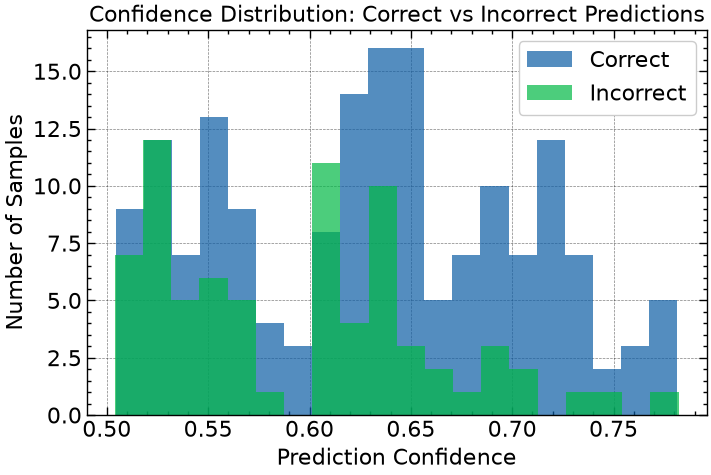

In [13]:
probs = model.predict_proba(X_test)
confidence = np.max(probs, axis=1)
predictions = model.predict(X_test)

correct = predictions == y_test.iloc[:,0]

plt.figure(figsize=(8, 5))

plt.hist(
    confidence[correct],
    bins=20,
    alpha=0.7,
    label="Correct"
)

plt.hist(
    confidence[~correct],
    bins=20,
    alpha=0.7,
    label="Incorrect"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Samples")
plt.title("Confidence Distribution: Correct vs Incorrect Predictions")
plt.legend()

plt.show()

The confidence distribution demonstrates that incorporating Team 1's score significantly improves the model's prediction reliability. Correct predictions dominate the higher confidence range (approximately 0.75–0.85), while incorrect predictions are primarily concentrated at lower confidence levels (0.50–0.70). Compared with the baseline model, the overlap between correct and incorrect confidence distributions is reduced, and the model exhibits fewer highly confident misclassifications. These observations suggest that Team 1's score is a highly informative feature, improving both the discriminative ability and confidence calibration of the classifier.

## Key Takeaways

- **Including Team 1's score significantly improved model interpretability**, making it the most influential feature in prediction.
- **Without Team 1's score, the model relied primarily on historical team performance, bowling statistics, and venue characteristics** to estimate match outcomes.
- **Historical features became secondary predictors** once the actual first-innings score was available, serving mainly to refine predictions.
- **SHAP analyses showed consistent agreement with feature importance rankings** in both models, confirming the reliability of the explainability results.
- **The findings align with cricket domain knowledge**, where the first-innings score is the strongest indicator of match outcome, while historical and venue-based statistics provide valuable contextual support.